# Feature Extraction Pipeline Walkthrough

This notebook documents the complete feature extraction pipeline used in this project.

Its purpose is to show, step by step, how a raw audio recording is transformed into fixed-size numerical features before being used for model training. The notebook mirrors the logic in `features.py` but includes visualizations and intermediate outputs for educational purposes.

This notebook is intended as documentation and is **not** part of the training pipeline.

## 1. Imports and Project Settings

Import the libraries and define the constants used throughout the feature extraction pipeline. These values match those used in `features.py` so the walkthrough reflects the actual preprocessing.

In [17]:
from pathlib import Path
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

SAMPLE_RATE = 16000
N_MFCC = 40
MAX_LEN = 250



## 2. Select a Sample Audio File

Choose a single audio file from the dataset. Using one file makes it easier to inspect every preprocessing step while keeping the code identical to the full pipeline.

In [18]:
PROJECT_DIR = Path.cwd().parent

real_dir =  PROJECT_DIR / "data" / "real"
fake_dir = PROJECT_DIR / "data" / "fake"

AUDIO_EXTENSIONS = {".wav", ".mp3", ".flac", ".ogg", ".m4a"}

def find_first_audio(folder):
    for file in folder.rglob("*"):
        if file.suffix.lower() in AUDIO_EXTENSIONS:
            return file
    return None

AUDIO_PATH = find_first_audio(real_dir)

print("Project folder:", PROJECT_DIR)
print("Selected audio:", AUDIO_PATH)

Project folder: /Users/joenikesh/Projects/Audio-Classification
Selected audio: /Users/joenikesh/Projects/Audio-Classification/data/real/jsut_real_00298.wav


## 3. Load and Standardize Audio

The audio is loaded with `librosa.load()`, converted to mono if necessary, and resampled to **16 kHz**. Standardizing the sampling rate ensures every recording is processed consistently regardless of its original format.

In [ ]:
import librosa
import numpy as np

# Load original recording exactly as stored in the file
audio_original, sr_original = librosa.load(
    AUDIO_PATH,
    sr=None,
    mono=True
)

# Load the same recording after librosa resamples it to 16 kHz
audio_resampled, sr_resampled = librosa.load(
    AUDIO_PATH,
    sr=SAMPLE_RATE,
    mono=True
)

# From here onward, use these simple names everywhere
audio = audio_resampled
sr = sr_resampled

print(f"Original Sample Rate : {sr_original} Hz")
print(f"After librosa.load() : {sr_resampled} Hz")

print("\nNumber of Samples")
print(f"Original Recording : {len(audio_original):,}")
print(f"After Resampling   : {len(audio_resampled):,}")

print("\nDuration")
duration_original = len(audio_original) / sr_original
duration_resampled = len(audio_resampled) / sr_resampled
print(f"Original Duration  : {duration_original:.2f} seconds")
print(f"Resampled Duration : {duration_resampled:.2f} seconds")

print("\nFirst 10 Samples (Original)")
print(audio_original[:10])

print("\nFirst 10 Samples (After librosa.load)")
print(audio_resampled[:10])

print("\nFirst 10 Samples (Original as 16-bit PCM integers)")
print((audio_original[:10] * 32767).astype(np.int16))

print("\nFirst 10 Samples (After librosa.load as 16-bit PCM integers)")
print((audio_resampled[:10] * 32767).astype(np.int16))


Original Sample Rate : 48000 Hz
After librosa.load() : 16000 Hz

Number of Samples
Original Recording : 784,320
After Resampling   : 261,440

Duration
Original Duration  : 16.34 seconds
Resampled Duration : 16.34 seconds

First 10 Samples (Original)
[0.00079346 0.00079346 0.00082397 0.00079346 0.00079346 0.00076294
 0.00076294 0.00079346 0.00079346 0.00076294]

First 10 Samples (After librosa.load)
[0.00053298 0.00086097 0.00074171 0.00079419 0.00072689 0.00075695
 0.0007874  0.00078828 0.00072487 0.00076847]

First 10 Samples (Original as 16-bit PCM integers)
[25 25 26 25 25 24 24 25 25 24]

First 10 Samples (After librosa.load as 16-bit PCM integers)
[17 28 24 26 23 24 25 25 23 25]


## 4. Visualize the Waveform

Display the standardized waveform. This represents the raw audio signal after loading and resampling, before any feature extraction occurs.

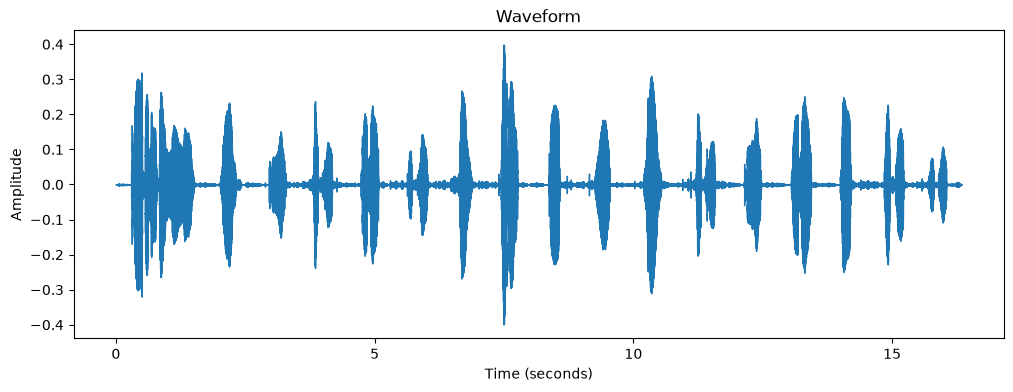

In [20]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio_resampled, sr=sr_resampled)
plt.title("Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

## 5. Padding and Trimming Utilities

Machine learning models require inputs with identical dimensions. These helper functions either truncate longer feature arrays or pad shorter ones with zeros so every sample has the same shape.

In [21]:
def pad_or_trim_2d(feature, max_len=MAX_LEN):
    print("Original 2D shape:", feature.shape)

    if feature.shape[1] < max_len:
        pad_width = max_len - feature.shape[1]
        print("Padding with", pad_width, "empty frames")
        feature = np.pad(feature, ((0, 0), (0, pad_width)), mode="constant")
    else:
        print("Trimming from", feature.shape[1], "frames to", max_len, "frames")
        feature = feature[:, :max_len]

    print("Final 2D shape:", feature.shape)
    return feature


def pad_or_trim_1d(feature, max_len=MAX_LEN):
    print("Original 1D shape:", feature.shape)

    if len(feature) < max_len:
        pad_width = max_len - len(feature)
        print("Padding with", pad_width, "empty values")
        feature = np.pad(feature, (0, pad_width), mode="constant")
    else:
        print("Trimming from", len(feature), "values to", max_len, "values")
        feature = feature[:max_len]

    print("Final 1D shape:", feature.shape)
    return feature

## 6. Extract MFCC Features

Compute Mel-Frequency Cepstral Coefficients (MFCCs), which capture the spectral characteristics of speech. The raw MFCC matrix is displayed before resizing so its original dimensions can be observed.

In [22]:
mfcc_raw = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=N_MFCC
)

print("Raw MFCC shape:", mfcc_raw.shape)
print("This means:")
print("MFCC rows:", mfcc_raw.shape[0])
print("Time frames:", mfcc_raw.shape[1])

Raw MFCC shape: (40, 511)
This means:
MFCC rows: 40
Time frames: 511


## 7. Visualize Raw MFCCs

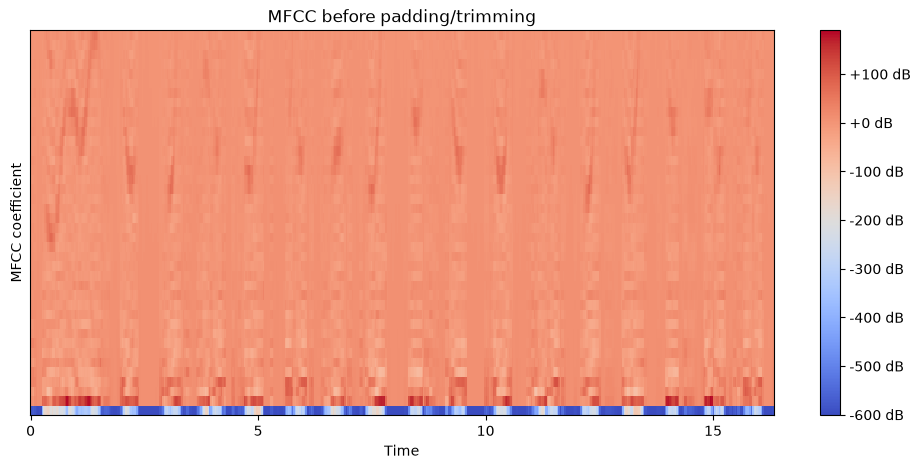

In [23]:
plt.figure(figsize=(12, 5))
librosa.display.specshow(mfcc_raw, sr=sr, x_axis="time")
plt.colorbar(format="%+2.0f dB")
plt.title("MFCC before padding/trimming")
plt.xlabel("Time")
plt.ylabel("MFCC coefficient")
plt.show()

## 8. Resize MFCC Matrix

Resize the MFCC matrix to the fixed shape used throughout the project: **(40, 250)**.

In [24]:
mfcc = pad_or_trim_2d(mfcc_raw)
print("Final MFCC shape:", mfcc.shape)

Original 2D shape: (40, 511)
Trimming from 511 frames to 250 frames
Final 2D shape: (40, 250)
Final MFCC shape: (40, 250)


## 9. Visualize Resized MFCCs

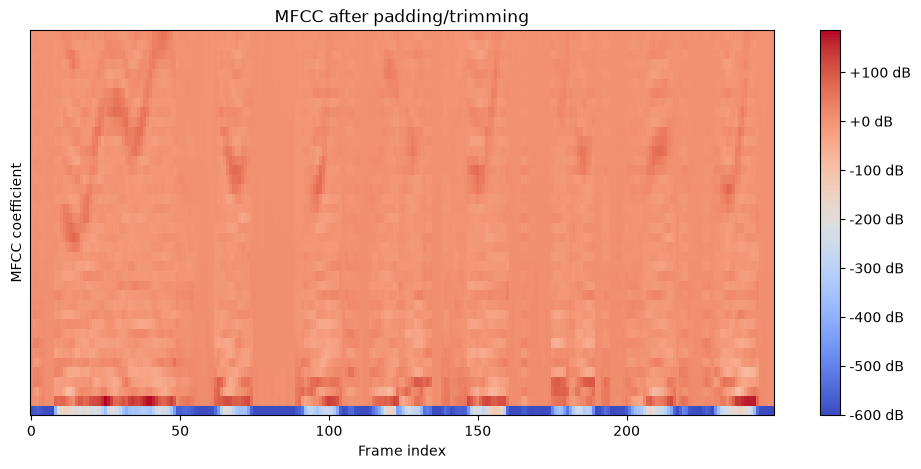

In [25]:
plt.figure(figsize=(12, 5))
librosa.display.specshow(mfcc, sr=sr, x_axis="frames")
plt.colorbar(format="%+2.0f dB")
plt.title("MFCC after padding/trimming")
plt.xlabel("Frame index")
plt.ylabel("MFCC coefficient")
plt.show()

## 10. Extract Pitch

Estimate the fundamental frequency (pitch) of the speech signal over time. Missing values from unvoiced regions are cleaned before resizing.

In [26]:
pitch_raw, voiced_flag, voiced_prob = librosa.pyin(
    audio,
    fmin=librosa.note_to_hz("C2"),
    fmax=librosa.note_to_hz("C7")
)

print("Raw pitch shape:", pitch_raw.shape)
print("Number of missing pitch values:", np.isnan(pitch_raw).sum())
print("First 20 raw pitch values:")
print(pitch_raw[:20])

pitch_clean = np.nan_to_num(pitch_raw)
print("First 20 cleaned pitch values:")
print(pitch_clean[:20])

Raw pitch shape: (511,)
Number of missing pitch values: 284
First 20 raw pitch values:
[         nan          nan          nan          nan          nan
          nan          nan          nan          nan 450.28451248
 432.44106336 447.69106453 455.51656649 460.80941404 460.80941404
 466.16376152 466.16376152 437.46578648 403.48177901 401.15789497]
First 20 cleaned pitch values:
[  0.           0.           0.           0.           0.
   0.           0.           0.           0.         450.28451248
 432.44106336 447.69106453 455.51656649 460.80941404 460.80941404
 466.16376152 466.16376152 437.46578648 403.48177901 401.15789497]


## 11. Resize Pitch Vector

Resize the pitch sequence to a fixed length of **250** frames.

In [27]:
pitch = pad_or_trim_1d(pitch_clean)
print("Final pitch shape:", pitch.shape)

Original 1D shape: (511,)
Trimming from 511 values to 250 values
Final 1D shape: (250,)
Final pitch shape: (250,)


## 12. Visualize Pitch

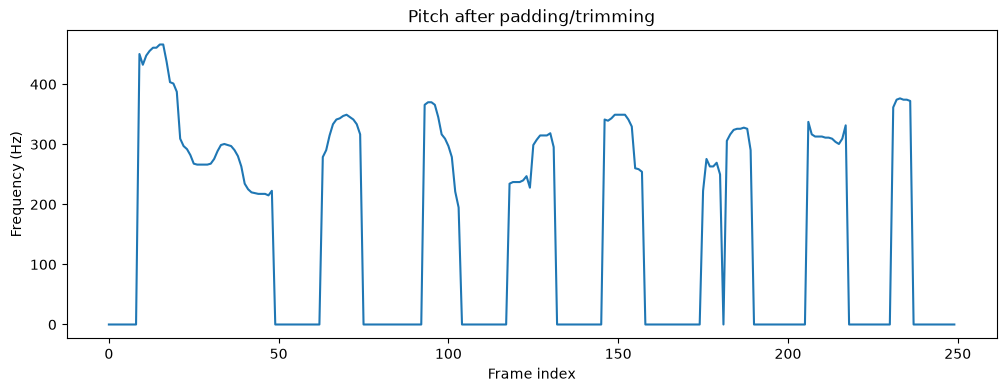

In [28]:
plt.figure(figsize=(12, 4))
plt.plot(pitch)
plt.title("Pitch after padding/trimming")
plt.xlabel("Frame index")
plt.ylabel("Frequency (Hz)")
plt.show()

## 13. Extract Energy

Compute Root Mean Square (RMS) energy, which represents the loudness of the signal over time.

In [29]:
energy_raw = librosa.feature.rms(y=audio)[0]

print("Raw energy shape:", energy_raw.shape)
print("First 20 raw energy values:")
print(energy_raw[:20])

Raw energy shape: (511,)
First 20 raw energy values:
[0.00045545 0.00057    0.00071112 0.00092627 0.00088982 0.00096589
 0.00088728 0.00073353 0.01527663 0.02500935 0.0518581  0.09489457
 0.12481783 0.14536732 0.14978985 0.12743543 0.10161161 0.08520994
 0.06809678 0.07244331]


## 14. Resize Energy Vector

Resize the energy sequence to the fixed length used throughout the dataset.

In [30]:
energy = pad_or_trim_1d(energy_raw)
print("Final energy shape:", energy.shape)

Original 1D shape: (511,)
Trimming from 511 values to 250 values
Final 1D shape: (250,)
Final energy shape: (250,)


## 15. Visualize Energy

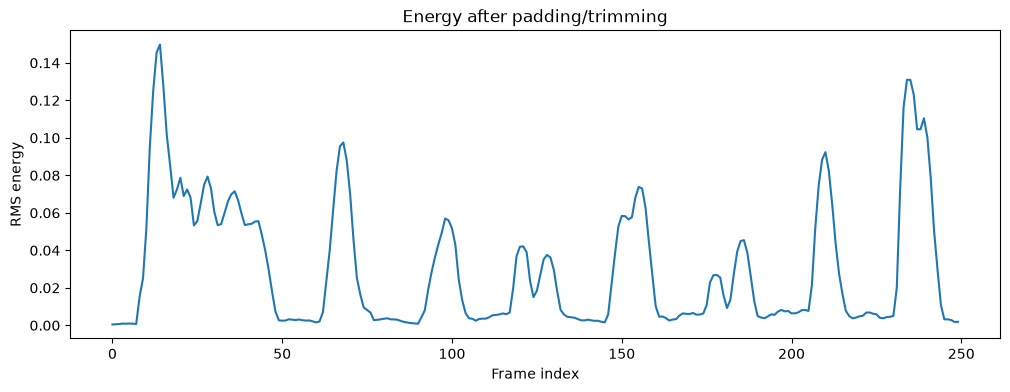

In [31]:
plt.figure(figsize=(12, 4))
plt.plot(energy)
plt.title("Energy after padding/trimming")
plt.xlabel("Frame index")
plt.ylabel("RMS energy")
plt.show()

## 16. Final Feature Extraction Function

This function combines all preprocessing steps into a reusable function. The training pipeline calls this function for every audio file in the dataset.

In [32]:
def load_audio(file_path, sample_rate=SAMPLE_RATE):
    audio, sr = librosa.load(
        file_path,
        sr=sample_rate,
        mono=True
    )
    return audio, sr


def extract_features(file_path):
    audio, sr = load_audio(file_path)

    # MFCC is 2D: rows = coefficients, columns = time frames
    mfcc_raw = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=N_MFCC
    )
    mfcc = pad_or_trim_2d(mfcc_raw)

    # Pitch is 1D: one pitch value per time frame
    pitch_raw, _, _ = librosa.pyin(
        audio,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7")
    )
    pitch_clean = np.nan_to_num(pitch_raw)
    pitch = pad_or_trim_1d(pitch_clean)

    # Energy is 1D: one loudness value per time frame
    energy_raw = librosa.feature.rms(y=audio)[0]
    energy = pad_or_trim_1d(energy_raw)

    return mfcc, pitch, energy


mfcc, pitch, energy = extract_features(AUDIO_PATH)

print("Final extracted feature shapes:")
print("MFCC:", mfcc.shape)
print("Pitch:", pitch.shape)
print("Energy:", energy.shape)


Original 2D shape: (40, 511)
Trimming from 511 frames to 250 frames
Final 2D shape: (40, 250)
Original 1D shape: (511,)
Trimming from 511 values to 250 values
Final 1D shape: (250,)
Original 1D shape: (511,)
Trimming from 511 values to 250 values
Final 1D shape: (250,)
Final extracted feature shapes:
MFCC: (40, 250)
Pitch: (250,)
Energy: (250,)


## 17. Final Output

After preprocessing, every audio recording is represented by three fixed-size feature arrays:

```text
MFCC   : (40, 250)
Pitch  : (250,)
Energy : (250,)
```

Because every sample has identical dimensions, the dataset can be efficiently batched and passed directly into the neural network during training.